# Part 1: Load and Understand the Data

In [29]:
from pydataset import data
import pandas as pd

In [30]:
df = data('mtcars')

In [31]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [32]:
df.shape #shape of the dataset

(32, 11)

### The dataset has 32 rows and 11 columns.

In [33]:
df.columns #column names

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

### The column names are: mpg, cyl, disp, hp, drat, wt, qsec, vs, am, gear, and carb.

In [34]:
df.dtypes #data types

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

### Data types for mtcars are numeric: int and float

In [35]:
df.describe() #summary statistics

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


### Summary statistics show count, mean, min, and max values.

In [36]:
df.isnull().sum() #any missing values

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

### There are no missing values in the dataset.

# Part 2: Basic Data Analysis

In [37]:
df['mpg'].mean()

np.float64(20.090625000000003)

### Average mileage (mpg): ~20.09

In [38]:
df['hp'].max()

335

### Maximum horsepower (hp): 335

In [39]:
df['wt'].min(), df['wt'].max()

(1.513, 5.424)

### Minimum weight (wt): 1.513
### Maximum weight (wt): 5.424

In [40]:
df['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

### 11 cars have 4 cylinders
### 7 cars have 6 cylinders
### 14 cars have 8 cylinders

In [41]:
df.groupby('cyl')['mpg'].mean()

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

### 4 cylinders: highest mpg (~26.66)
### 6 cylinders: moderate (~19.74)
### 8 cylinders: lowest (~15.10)

# Part 3: Intermediate Analysis

In [42]:
df.groupby('am')['mpg'].mean()  

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

### Manual cars (1) have higher mpg than automatic (0).

In [43]:
df.groupby('gear')['mpg'].mean()

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

### Cars with more gears tend to have better mileage.

In [44]:
pd.pivot_table(df, values='mpg', index='cyl', columns='am')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [45]:
df['efficiency'] = df['mpg'].apply(lambda x: 'High' if x > 20 else 'Low')

In [46]:
df['am'] = df['am'].map({0: 'Automatic', 1: 'Manual'})

In [47]:
df['vs'] = df['vs'].map({0: 'V-shaped', 1: 'Straight'})

# Part 4: Data Visualization

In [48]:
import matplotlib.pyplot as plt

In [49]:
import seaborn as sns

## Chart 1: Bar Chart (mpg by cylinders)

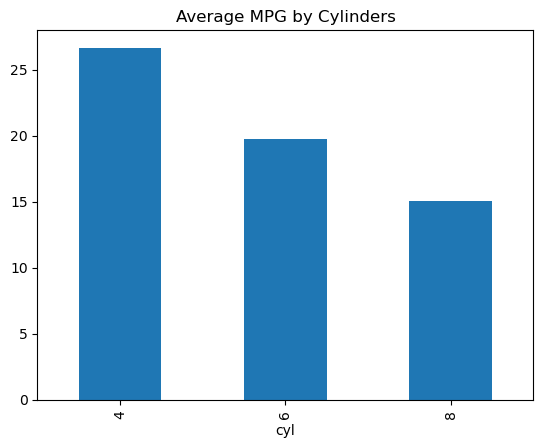

In [50]:
df.groupby('cyl')['mpg'].mean().plot(kind='bar')
plt.title("Average MPG by Cylinders")
plt.show()

### Observation: Cars with fewer cylinders have better fuel efficiency.

## Chart 2: Scatter Plot (wy vs mpg)

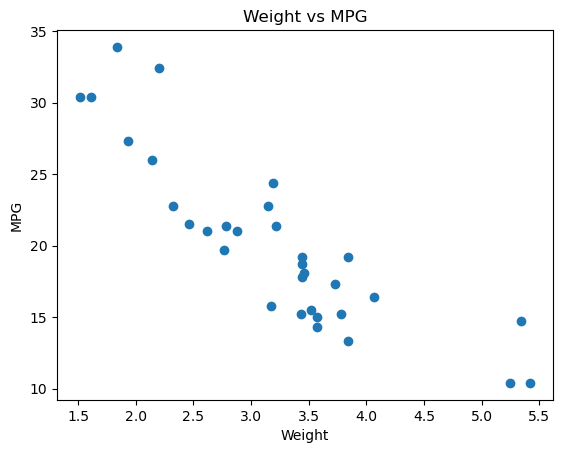

In [51]:
plt.scatter(df['wt'], df['mpg'])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

### Observation: Heavier cars tend to have lower mileage.

## Chart 3: Histogram (horsepower)

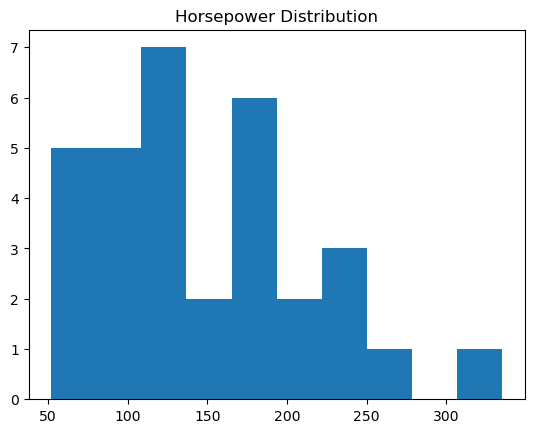

In [52]:
plt.hist(df['hp'])
plt.title("Horsepower Distribution")
plt.show()

### Observation: Most cars have moderate horsepower, with few high-performance cars.

## Chart 4: Boxplot (mpg by transmission)

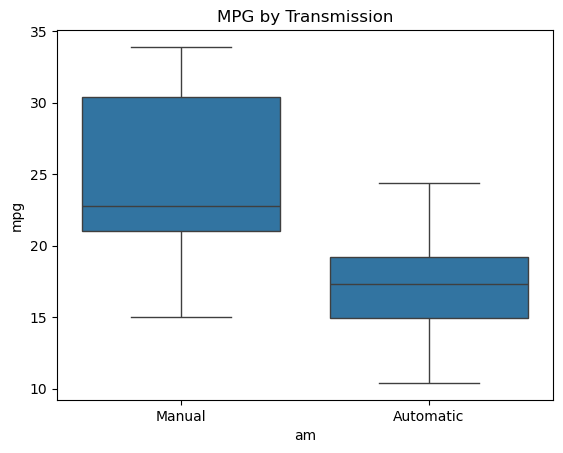

In [53]:
sns.boxplot(x='am', y='mpg', data=df)
plt.title("MPG by Transmission")
plt.show()

### Observation: Manual cars generally have better mileage than automatic cars.

# INSIGHTS
- Cars with 4 cylinders have the highest fuel efficiency.
- Heavier cars have lower mpg.
- Cars with more gears tend to have higher mpg.
- Manual transmission cars perform better in fuel efficiency.
- Lighter cars are generally more efficient.
- High-horsepower cars usually consume more fuel.


# CONCLUSION
The analysis of the mtcars dataset shows relationships between vehicle characteristics and fuel efficiency. Cars with fewer cylinders and lower weight are made more efficient due to their higher mileage. The fuel performance of manual-transmission vehicles is better than that of automatic-transmission vehicles. The vehicles with higher horsepower and more cylinders generally consume more fuel. Overall, the dataset highlights the influence of weight and engine on car efficiency and performance. 